# Data / Model Init

In [1]:
# N_SAMPLES = 10000
N_SAMPLES = None
random_state = 11
fold_id = 0

FILTERS = {
    "duration_unit": ["h"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}

SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    possible = Path.cwd() / "vollmers/gnn-thesis/gnn-thesis"
    if (possible / "src").exists():
        PROJECT_ROOT = possible

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import process_data, print_mol_types
from src.data.graph_building import build_graphs
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.data.splitting import butina_split, show_split_info
from src.data.sampling import LoadData, show_loader_info, display_sampling_effect
from src.training.loops import train
from src.visualization.training_plots import  plot_training, plot_training_metrics, plot_group_training


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

print("Imports imported")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports imported


In [2]:
DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

print(f"Data path: {DATA_PATH}")

df_all = load_data(DATA_PATH)

df_processed = process_data(
    df_all,
    n_samples=N_SAMPLES,
    random_state=random_state,
    filters=FILTERS,
    require_duration=False,
    require_taxid=True,
    split_salts=SPLIT_SALTS,
    remove_lone=REMOVE_LONE,
    remove_metals=REMOVE_METALS,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

df_processed


Data path: /home/vollmers/gnn-thesis/Data/toxicity_all.csv
Filters
conc > 0 and <= 10000
True: 0.990
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxid: True
True: 0.995
duration <= 9000.0 h or missing
True: 0.986

Loaded and masked training data
Rows in full data: 561,100
Rows after mask: 525,852
Rows before preprocessing: 525,852
Rows after preprocessing:  525,852
Rows removed: 0


,SK_unique_id,species_common_name,species_latin_name,CAS,chemical_name,conc_unit,conc,duration,duration_unit,effect,endpoint,SMILES,organism_lifestage,administration_route,species_sci_name,taxid,superkingdom,kingdom,phylum,subphylum,class,order,family,genus,species,species_group,log10c,duration_raw
0,RTECS7,mouse,Mus musculus,108073-64-9,"5H-Pyrrolo(2,1-c)(1,4)benzodiazepin-5-one, 1,2,3,10,11,11a-hexahydro-2-hydro...",mg/kg,36.200,-6.000000,h,MOR,EC50,COC1Nc2ccccc2C(=O)N2CC(O)CC12,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,1.558709,NaN
1,RTECS41,mouse,Mus musculus,78111-17-8,"Acanthifolicin, 9,10-deepithio-9,10-didehydro-",mg/kg,0.192,-6.000000,h,MOR,EC50,C=C1C(O)C2OC3(CCC(C=CC(C)C4CC(C)=CC5(OC(CC(C)(O)C(=O)O)CCC5O)O4)O3)CCC2OC1C(...,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,-0.716699,NaN
2,RTECS137,mouse,Mus musculus,4657-93-6,5-Acenaphthenamine,mg/kg,56.000,-6.000000,h,MOR,EC50,Nc1ccc2c3c(cccc13)CC2,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,1.748188,NaN
3,RTECS140,mouse,Mus musculus,102585-20-6,"5-Acenaphthenamine, 6,7,8,8a-tetrahydro-N-(2-oxazolin-2-yl)-",mg/kg,100.000,-6.000000,h,MOR,EC50,c1cc(NC2=NCCO2)c2c3c1CCC3CCC2,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,2.000000,NaN
4,RTECS141,rat,Rattus norvegicus,83-32-9,Acenaphthene,mg/kg,600.000,-6.000000,h,MOR,EC50,c1cc2c3c(cccc3c1)CC2,adult,fill,rattus norvegicus,10116,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10114.0,10116.0,rodents,2.778151,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525847,AQTER1441956,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.041,2.283301,h,GRO,LOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-1.387216,192.0
525848,AQTER1441958,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.640,1.982271,h,GRO,LOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.193820,96.0
525849,AQTER1441960,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.160,1.982271,h,GRO,NOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.795880,96.0
525850,AQTER1441966,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.640,1.982271,h,GRO,NOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.193820,96.0


In [3]:
from src.data.simple_featurizer import simple_featurizer
from src.data.features_graph import GraphFeaturizer

ATOM_FEATURES = (
    "atomic_num",
    "degree",
    "formal_charge",
    "num_hs",
    "hybridization",
    "is_aromatic",
    "is_in_ring",
    "atomic_mass",
    "period",
    "group",
    "covalent_radius",
    "vdw_radius",
    "is_metal",
)

BOND_FEATURES = (
    "bond_order",
    "is_conjugated",
    "is_in_ring",
    "stereo",
)

graph_featurizer = GraphFeaturizer(ATOM_FEATURES, BOND_FEATURES)

df_processed["features"] = df_processed["SMILES"].apply(graph_featurizer.featurize)

graph_cache = graph_featurizer.get_graph_cache()

from src.data.features_mol import add_molecule_metadata

MOLECULE_CATEGORICAL_COLS = [
    "is_salt",
    "has_metal",
    "is_single_node",
]

MOLECULE_NUMERICAL_COLS = [
    "fragment_count",
    # "mol_weight",
    "log10_mol_weight",
    # "logp",
    # "tpsa",
    # "log10_tpsa_plus1",
    # "h_bond_donor_count",
    # "h_bond_acceptor_count",
    # "heavy_atom_count",
    # "log10_heavy_atom_count_plus1",
    # "hetero_atom_count",
    # "halogen_count",
    # "metal_count",
    # "transition_metal_count",
    # "ring_count",
    # "aromatic_ring_count",
    # "rotatable_bond_count",
    "formal_charge",
]

# Add molecule-level metadata for categorical and numerical encoders
df_processed = add_molecule_metadata(df_processed, categorical_cols=MOLECULE_CATEGORICAL_COLS, numerical_cols=MOLECULE_NUMERICAL_COLS)

USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = PROJECT_ROOT / "Data" / "moredata" / "pretrained_tax_emb.pkl.zip"
print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

config_tax = {}

# Categorical encoding
exp_categorical_cols = [
    "species_group",
    "conc_unit",
    "endpoint", 
    "effect"
]

CATEGORICAL_COLS = exp_categorical_cols + MOLECULE_CATEGORICAL_COLS

df_categorical = df_processed[CATEGORICAL_COLS].copy()
df_categorical, categorical_encoder = sequential_encoder(df_categorical, CATEGORICAL_COLS)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, CATEGORICAL_COLS)

species_group_decoder = {encoded: original for original, encoded in categorical_encoder["species_group"].items()}

NUMERICAL_COLS = ["duration"] + MOLECULE_NUMERICAL_COLS

graphs = build_graphs(
    df_processed,  
    df_categorical,
    CATEGORICAL_COLS,
    NUMERICAL_COLS,
    )

from src.data.splitting import _build_dataset

full_dataset = _build_dataset(graphs, range(len(graphs)))

Pretrained taxid path: /home/vollmers/gnn-thesis/Data/moredata/pretrained_tax_emb.pkl.zip


In [4]:
import re

EXPERIMENT_DIR = PROJECT_ROOT / "outputs" / "experiments"
fold_pattern = re.compile(r"fold_(\d+)_val_predictions\.csv\.gz$")


def load_model_folds(model_name):
    model_dir = EXPERIMENT_DIR / model_name
    frames = []

    for path in sorted(model_dir.glob("fold_*_val_predictions.csv.gz")):
        fold = int(fold_pattern.search(path.name).group(1))

        df = pd.read_csv(path, compression="gzip")
        df["fold"] = fold
        df["model"] = model_name

        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No fold prediction files found in {model_dir}")

    return pd.concat(frames, ignore_index=True)

afp_df = load_model_folds("afp-11M-10fold")

In [5]:
afp_df[afp_df["abs_error_log10c"] < 0.0001].sort_values(by="actual_log10c")[["SMILES", "actual_log10c", "pred_log10c", "abs_error_log10c", "fold", "row_id"]]

,SMILES,actual_log10c,pred_log10c,abs_error_log10c,fold,row_id
525525,O=C(NC(=O)c1c(F)cccc1F)Nc1cc(Cl)c(F)c(Cl)c1F,-5.148742,-5.148716,0.000026,9,523128
181036,Nc1c(Cl)c(Cl)nc(C(=O)O)c1Cl,-4.552842,-4.552890,0.000048,3,220701
335952,CCOP(=S)(OCC)SCSC(C)(C)C,-3.950453,-3.950354,0.000098,6,200280
284527,O=S1OCC2C(CO1)C1(Cl)C(Cl)=C(Cl)C2(Cl)C1(Cl)Cl,-3.950453,-3.950397,0.000056,5,213283
91913,CCNc1nc(Cl)nc(NCC)n1,-3.903090,-3.903131,0.000041,1,416206
494149,CNC(=O)Oc1cc(C)c(SC)c(C)c1,-3.769551,-3.769475,0.000076,9,209538
49218,CSc1nc(NC(C)C)nc(NC(C)C)n1,-2.086186,-2.086196,0.000010,0,478445
391199,CCOP(=S)(OCC)SCCSCC,-1.744727,-1.744639,0.000088,7,243445
242684,CCNc1nc(Cl)nc(NC(C)C)n1,-1.709298,-1.709253,0.000044,4,334027
313067,CCc1cc(C)cc(CC)c1-c1c(OC(=O)C(C)(C)C)n2n(c1=O)CCOCC2,-1.511449,-1.511372,0.000077,5,505917


In [9]:
from torch_geometric.data import Batch
import torch

graph = graphs[478445].to(device)
g = graph.clone()

if hasattr(g, "batch"):
    del g.batch

batch = Batch.from_data_list([g]).to(device)

model.eval()
with torch.no_grad():
    pred_log10c = model(batch).view(-1).item()

pred_log10c

-2.086195707321167

In [5]:
loader = LoadData(
    dataset=full_dataset, 
    batch_size=256, 
    sampler_type="sequential",
    shuffle=False, 
    attribute="species_group",
    target_dataset=full_dataset
)

In [6]:
from src.models.pna import compute_pna_degree_histogram

from src.models.grapefruit import Grapefruit
from src.models.attentive_fp import AttentiveFP
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########## MODEL HYPERPARAMETERS ##########

PRETRAINED_TAX_DIM = 768 # 768 is the length of the vectors in pretrained_tax_emb.pkl.zip
PRETRAINED_TAXID_OUTPUT_DIM = 512
CATEGORICAL_DIM = 128
NUMERIC_DIM = 128
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 512
GNN_OUT_DIM = 512
TOWERS = 4

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.3

FINAL_HIDDEN_DIM = 1024

ATOM_FEATURE_DIM = graphs[0].x.shape[1]
EDGE_FEATURE_DIM = graphs[0].edge_attr.shape[1]
VIRTUAL_EDGE_FEATURE_DIM = graphs[0].virtual_edge_attr.shape[1] if hasattr(graphs[0], "virtual_edge_attr") else 0

def build_model():
    meta_encoder = MetaEncoder(
        pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
        pretrained_tax_dim=PRETRAINED_TAX_DIM,
        pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
        config_categorical=config_categorical,
        categorical_output_dim=CATEGORICAL_DIM,
        numerical_columns=NUMERICAL_COLS,
        numeric_output_dim=NUMERIC_DIM,
        dropout=META_DROPOUT
    ).to(device)

    # meta_encoder = None

    # pna_deg = compute_pna_degree_histogram(full_dataset)

    # model_gnn = Grapefruit(
    #     in_channels=ATOM_FEATURE_DIM,
    #     edge_dim=EDGE_FEATURE_DIM,
    #     virtual_edge_dim=VIRTUAL_EDGE_FEATURE_DIM,
    #     hidden_dim=GNN_HIDDEN_DIM,
    #     towers=TOWERS,
    #     deg=pna_deg,
    #     out_dim=GNN_OUT_DIM,
    #     num_layers=NUM_LAYERS,
    #     num_timesteps=NUM_TIMESTEPS,
    #     dropout=DROPOUT,
    # ).to(device)

    model_gnn = AttentiveFP(
        in_channels=ATOM_FEATURE_DIM,
        edge_dim=EDGE_FEATURE_DIM,
        hidden_channels=GNN_HIDDEN_DIM,
        out_channels=GNN_OUT_DIM,
        num_layers=NUM_LAYERS,
        num_timesteps=NUM_TIMESTEPS,
        dropout=0.3,
    ).to(device)

    # model_gnn = None

    model = ToxicityModel(
        model_gnn,
        meta_encoder,
        hidden_dim=FINAL_HIDDEN_DIM,
    ).to(device)

    n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad) if meta_encoder else 0
    n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad) if model_gnn else 0
    n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gnn_name = type(model_gnn).__name__ if model_gnn is not None else "metadata_only"

    return model, meta_encoder, model_gnn, n_params_meta, n_params_gnn, n_params_total, gnn_name

model, meta_encoder, model_gnn, *_ = build_model()

# checkpoint_path = PROJECT_ROOT / "outputs" / "models" / "Grapefruit-9M-150-fold0.pt"

checkpoint_path = PROJECT_ROOT / "outputs" / "models" / "afp-11M-10fold" / "AttentiveFP-11M-fold0.pt"


checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

model.eval()

print(f"Loaded model from {checkpoint_path}")
print(f"Best epoch: {checkpoint.get('best_epoch')}")
print(f"Best score: {checkpoint.get('best_monitor_value')}")

Loaded model from /home/vollmers/gnn-thesis/outputs/models/afp-11M-10fold/AttentiveFP-11M-fold0.pt
Best epoch: 135
Best score: 0.6582199082924769


In [7]:
checkpoint_path = PROJECT_ROOT / "outputs/models/afp-11M-10fold/AttentiveFP-11M-fold0.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model, meta_encoder, model_gnn, *_ = build_model()
model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model = model.to(device).eval()

from torch_geometric.loader import DataLoader
import pandas as pd
import torch

fold_path = PROJECT_ROOT / "outputs/experiments/afp-11M-10fold/fold_00_val_predictions.csv.gz"
fold = 0
fold_df = pd.read_csv(fold_path)

# include the suspicious row plus some random rows
row_ids = [381498] + fold_df.sample(20, random_state=0)["row_id"].astype(int).tolist()
row_ids = list(dict.fromkeys(row_ids))

loader = DataLoader([graphs[i] for i in row_ids], batch_size=64, shuffle=False)

model.eval()
rows = []
with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch).view(-1).detach().cpu().numpy()
        ids = batch.row_id.detach().cpu().view(-1).numpy().astype(int)
        rows.extend(zip(ids, pred))

recomputed = pd.DataFrame(rows, columns=["row_id", "recomputed_pred"])
check = fold_df.merge(recomputed, on="row_id", how="inner")
check["diff"] = check["recomputed_pred"] - check["pred_log10c"]

check[["row_id", "pred_log10c", "recomputed_pred", "diff", "actual_log10c", "SMILES"]]

,row_id,pred_log10c,recomputed_pred,diff,actual_log10c,SMILES
0,7502,1.181963,1.181963,4.375610e-08,-0.096910,CC[N+](C)(CC)CCOC(=O)c1ccc(C(=O)OCC[N+](C)(CC)CC)c(-c2ccccc2)c1-c1ccccc1.[I-...
1,9871,3.148470,3.148470,2.017639e-07,2.949878,COc1cc(N)c2c(c1N)C(=O)c1ccccc1C2=O
2,57714,2.153052,2.153052,-2.084015e-07,1.973128,Cc1cc(C(=O)NNC(C)Cc2ccccc2)no1
3,66065,2.427421,2.427421,-1.454315e-07,3.340444,CCCC1CC(C(=O)NC(C(C)Cl)C2OC(SC)C(O)C(O)C2O)N(C)C1
4,141714,1.001792,1.001792,-2.459595e-07,2.000000,CN(C)CCOCCN(C)CCCN
5,146115,0.633788,0.633789,3.260582e-07,-0.510886,C=CC(=O)OCCCCCCCCCCOC(=O)C=C
6,150822,-0.495742,-0.495742,-6.378189e-08,-0.522879,CC(C)(C)CCCCCC(=O)[O-].CC(C)(C)CCCCCC(=O)[O-].[Cu+2]
7,223822,0.483592,0.483592,-1.185905e-07,1.400365,S=C=S
8,230047,2.405137,2.405137,2.365417e-08,2.301030,O=S(=O)([O-])[O-].[Cu+2]
9,234760,-5.463816,-5.463816,3.109131e-07,-5.899630,CCSC(C)CC1CC(=O)C(C(CC)=NOCC=CCl)=C(O)C1


# Interpretability

## Mol heatmaps

In [10]:
from torch_geometric.data import Data
from torch import nn

class ExplainerWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(
        self,
        x,
        edge_index,
        edge_attr=None,
        virtual_edge_index=None,
        virtual_edge_attr=None,
        fragment_id=None,
        batch=None,
    ):
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            virtual_edge_index=virtual_edge_index,
            virtual_edge_attr=virtual_edge_attr,
            fragment_id=fragment_id,
            batch=batch,
        )
        return self.model(data)

In [12]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer, AttentionExplainer

algorithm = GNNExplainer(epochs=100)
# algorithm = AttentionExplainer

explainer = Explainer(
    model=ExplainerWrapper(model_gnn),
    algorithm=algorithm,
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type=None,
    model_config=dict(
        mode="regression",
        task_level="graph",
    )
)

graph = graphs[478445].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)



In [13]:
import torch
from IPython.display import display

print(graph.smiles)
print(graph)
print()
print(explanation) # node_mask shape: [num_nodes, num_node_features] - "how important each atoms node feature was for the prediction"
print()

node_mask = explanation.node_mask.cpu().detach().numpy()
node_importance = node_mask.sum(axis=1)
print(node_importance)
feature_importance = node_mask.sum(axis=0)

CSc1nc(NC(C)C)nc(NC(C)C)n1
Data(x=[16, 187], edge_index=[2, 32], edge_attr=[32, 14], virtual_edge_index=[2, 0], virtual_edge_attr=[0, 10], fragment_id=[16], num_fragments=[1], smiles='CSc1nc(NC(C)C)nc(NC(C)C)n1', y=-2.086186170578003, row_id=478445, taxid_raw=307507, species_group=14, conc_unit=1, endpoint=2, effect=5, is_salt=0, has_metal=0, is_single_node=0, duration=1.6812412738800049, fragment_count=1.0, log10_mol_weight=2.3822622299194336, formal_charge=0.0, batch=[16])

Explanation(node_mask=[16, 187], prediction=[1, 512], target=[1, 512], x=[16, 187], edge_index=[2, 32], edge_attr=[32, 14], virtual_edge_index=[2, 0], virtual_edge_attr=[0, 10], fragment_id=[16], batch=[16])

[3.5752816 4.5486646 3.6425295 4.208418  3.622364  3.7931354 3.724811
 3.6470249 3.7099717 4.1792126 3.5111957 3.807525  3.5366025 3.659733
 3.5458763 4.0159197]


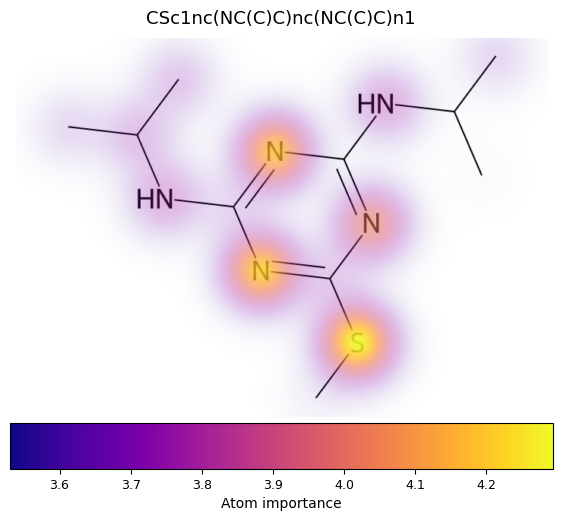

In [14]:
from src.visualization.interpretability import draw_atom_heatmap_gaussian

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.05,
    alpha=0.90,
)


CSc1nc(NC(C)C)nc(NC(C)C)n1


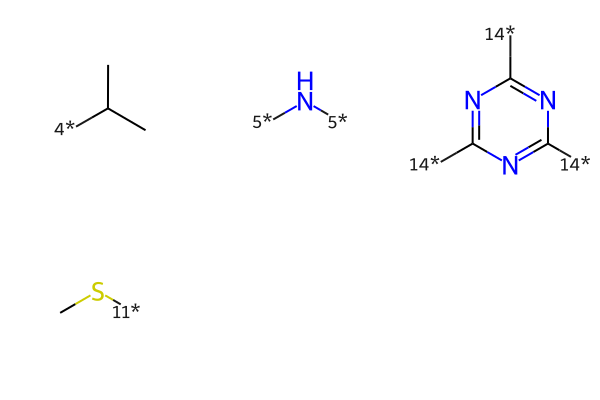

In [15]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import BRICS
import rdkit

print(graph.smiles)

mol = Chem.MolFromSmiles(graph.smiles)

rdDepictor.Compute2DCoords(mol)

mol
pieces = BRICS.BRICSDecompose(mol)
pieces

Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in pieces])

In [16]:
from src.visualization.interpretability import build_atom_feature_index, plot_node_feature_importance

# feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

# feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))

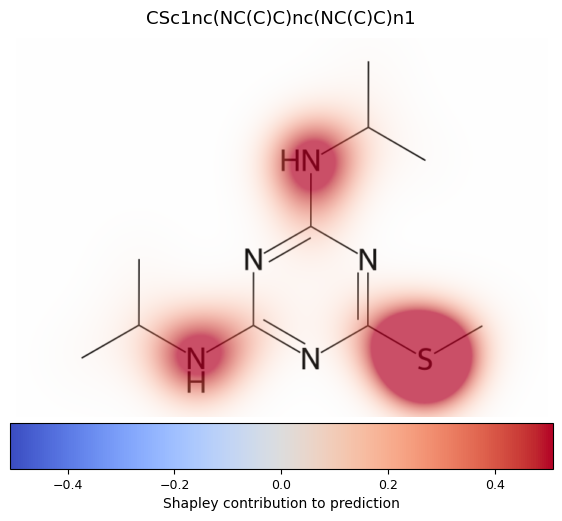

array([ 0.06499171,  0.98689693,  0.21131688, -0.01529569,  0.1718564 ,
        0.53827989,  0.07724627,  0.04674491,  0.03722564, -0.00387776,
        0.17087077,  0.51639247,  0.08492217,  0.0499769 ,  0.04478001,
       -0.00453027])

In [16]:
from src.visualization.interpretability import atom_shapley_permutation, draw_atom_shapley_heatmap_gaussian

shapley = atom_shapley_permutation(model, graph, n_samples=500)
tox_score = -shapley

draw_atom_shapley_heatmap_gaussian(
    graph.smiles,
    tox_score,
    cmap_name="coolwarm",
    sigma_frac=0.07,
)

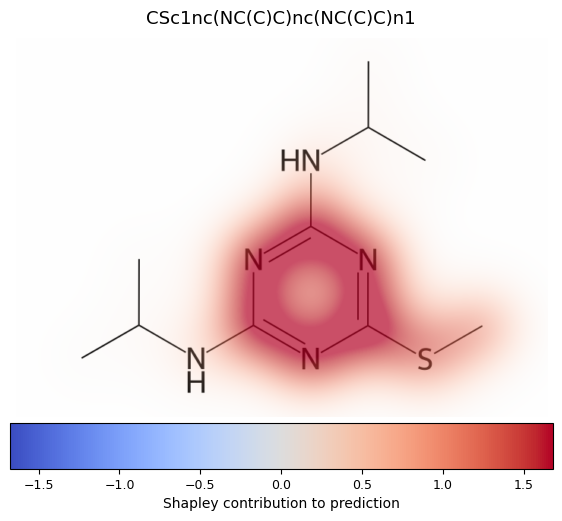

brics [2, 6, 1, 3, 1, 3]


In [17]:
from src.visualization.interpretability import  get_interpretability_atom_groups, group_shapley_permutation, draw_group_shapley_heatmap_gaussian

groups, group_method = get_interpretability_atom_groups(
    graph.smiles,
    return_method=True,
)

shapley_group = group_shapley_permutation(model, graph, groups)
tox_group = -shapley_group

draw_group_shapley_heatmap_gaussian(
    graph.smiles,
    groups,
    tox_group,
    cmap_name="coolwarm",
    sigma_frac=0.07,
)

print(group_method, [len(group) for group in groups])


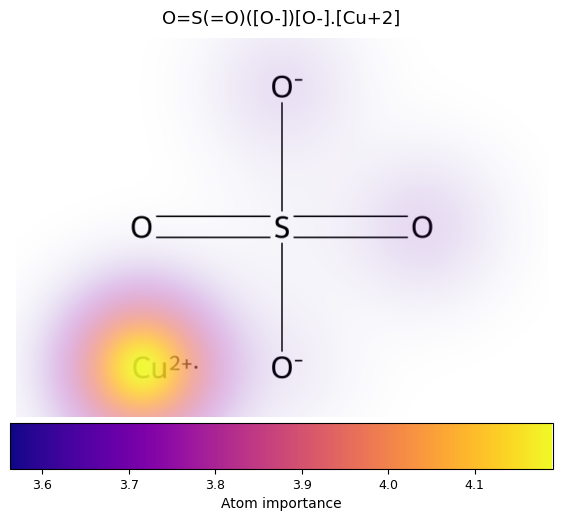

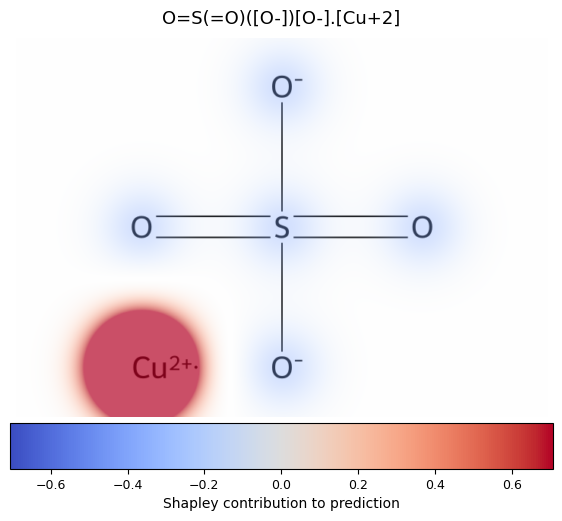

disconnected_components [5, 1]


In [18]:
graph = graphs[276540].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)

# feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

# feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))


# shapley = atom_shapley_permutation(model, graph)

# draw_atom_shapley_heatmap_gaussian(
#     graph.smiles,
#     shapley,
#     cmap_name="coolwarm",
#     sigma_frac=0.07,
# )

groups, group_method = get_interpretability_atom_groups(
    graph.smiles,
    return_method=True,
)

shapley_group = group_shapley_permutation(model, graph, groups)
tox_group = -shapley_group

draw_group_shapley_heatmap_gaussian(
    graph.smiles,
    groups,
    tox_group,
    cmap_name="coolwarm",
    sigma_frac=0.07,
)

print(group_method, [len(group) for group in groups])


In [33]:
from src.visualization.interpretability import predict_graph, predict_with_atom_mask

g = graph.to(device)

full_pred = predict_graph(model, g, device)

empty_mask = torch.zeros(g.x.size(0), dtype=torch.bool, device=g.x.device)
baseline_x = torch.zeros_like(g.x)
masked_pred = predict_with_atom_mask(model, g, empty_mask, baseline_x)

shapley = group_shapley_permutation(model, g, groups, n_samples=1000)

print("full pred log10c:", full_pred)
print("masked baseline log10c:", masked_pred)
print("sum shapley log10c:", shapley.sum().item())
print("baseline + shapley:", masked_pred + shapley.sum().item())

print("full toxicity score:", -full_pred)
print("baseline toxicity score:", -masked_pred)
print("sum toxicity shapley:", (-shapley).sum().item())

full pred log10c: 1.8141601085662842
masked baseline log10c: 1.5828824043273926
sum shapley log10c: 0.23127830028533936
baseline + shapley: 1.814160704612732
full toxicity score: -1.8141601085662842
baseline toxicity score: -1.5828824043273926
sum toxicity shapley: -0.23127830028533936


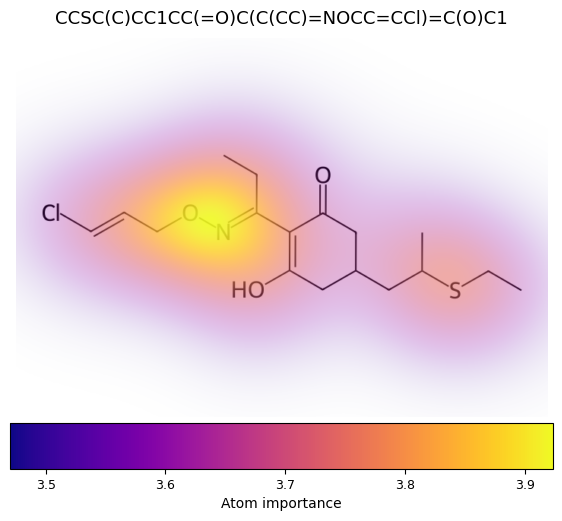

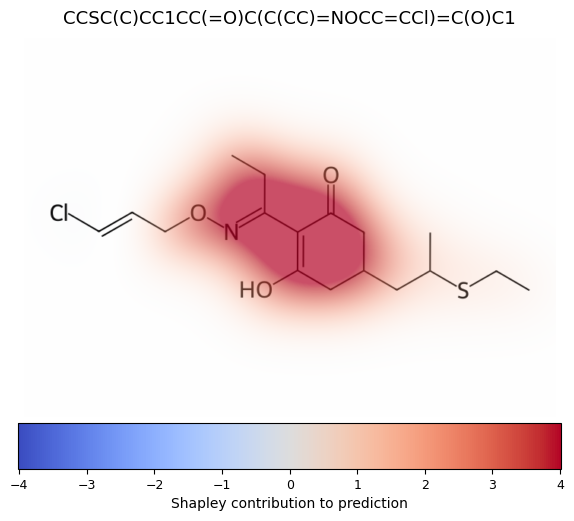

constrained_cc_single_bonds [6, 8, 6, 3]


In [19]:
graph = graphs[234760].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)

# feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

# feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))


# shapley = atom_shapley_permutation(model, graph)

# draw_atom_shapley_heatmap_gaussian(
#     graph.smiles,
#     shapley,
#     cmap_name="coolwarm",
#     sigma_frac=0.07,
# )

groups, group_method = get_interpretability_atom_groups(
    graph.smiles,
    return_method=True,
)

shapley_group = group_shapley_permutation(model, graph, groups)
tox_group = -shapley_group

draw_group_shapley_heatmap_gaussian(
    graph.smiles,
    groups,
    tox_group,
    cmap_name="coolwarm",
    sigma_frac=0.07,
)

print(group_method, [len(group) for group in groups])


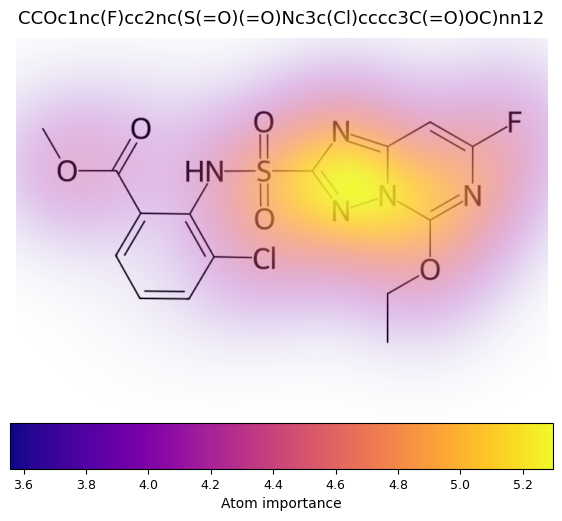

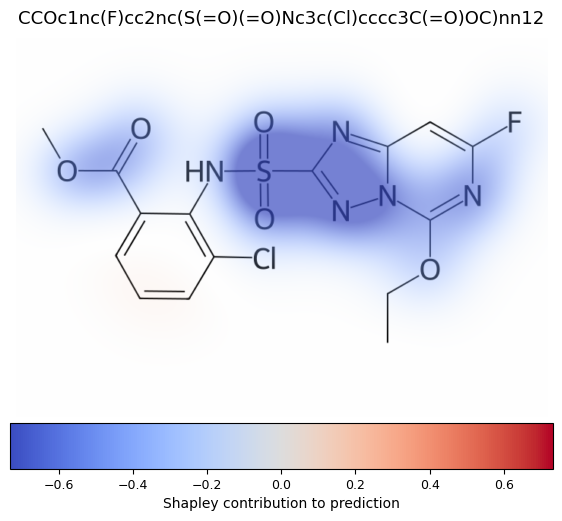

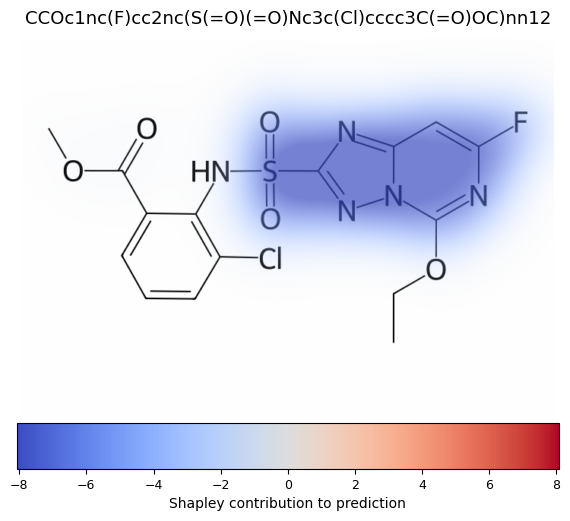

brics [2, 1, 13, 1, 7, 2, 2]


In [20]:
graph = graphs[381498].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)

# feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

# feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))


shapley = atom_shapley_permutation(model, graph)

draw_atom_shapley_heatmap_gaussian(
    graph.smiles,
    shapley,
    cmap_name="coolwarm",
    sigma_frac=0.07,
    save_path="atom_shapley_heatmap.png",
)

groups, group_method = get_interpretability_atom_groups(
    graph.smiles,
    return_method=True,
)

shapley_group = group_shapley_permutation(model, graph, groups)

draw_group_shapley_heatmap_gaussian(
    graph.smiles,
    groups,
    shapley_group,
    cmap_name="coolwarm",
    sigma_frac=0.07,
    save_path="atom_shapley_heatmap.png",
)

print(group_method, [len(group) for group in groups])
